# 💻 **Evidencia 1**

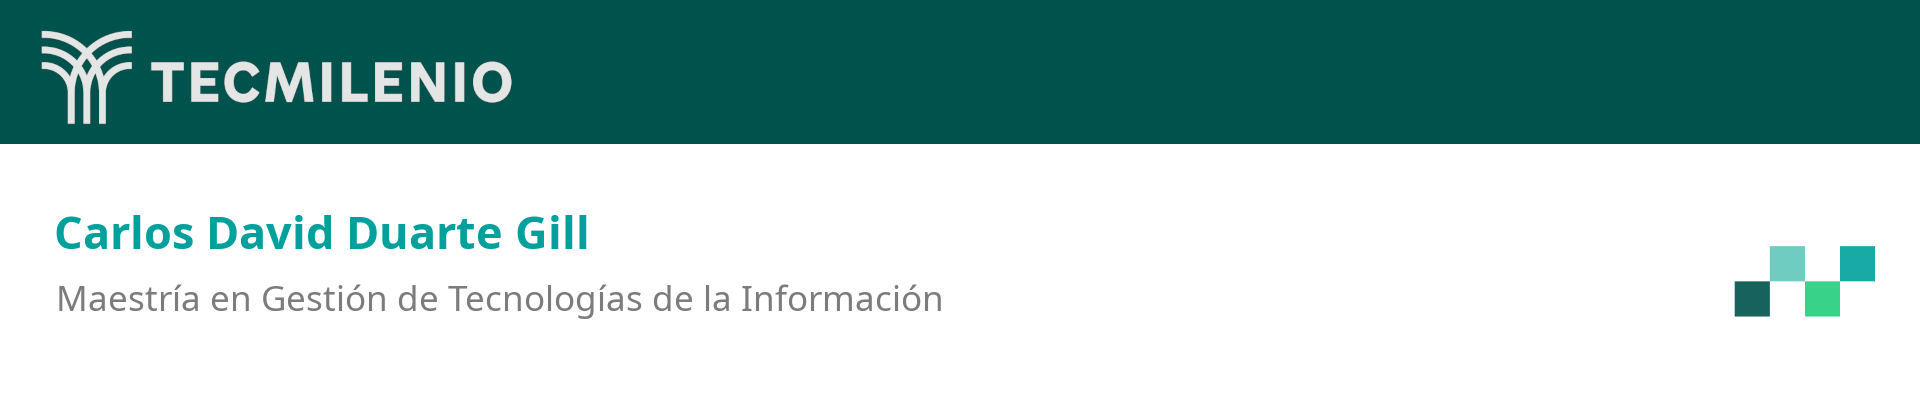

## **Gestión de calidad de datos**

- Alumno: Carlos David Duarte Gill
- Matricula: 7089642
- Correo: AL07089642@tecmilenio.mx
- Profesor: Heriberto Gonzalez Cazares
- Fecha:  domingo 28 de febrero de 2026

*Cursando la Maestría en Gestión de Tecnologías de la Información*

# 📘 Introducción – Evidencia 1

Esta Evidencia representa la consolidación práctica de los conocimientos adquiridos sobre el ciclo de vida de los datos, con un enfoque crítico en la calidad y la integridad. En un entorno empresarial donde los volúmenes de información crecen exponencialmente, como ocurre en sectores de alta regulación como los seguros y el retail, no basta con procesar datos; es imperativo garantizar que estos sean precisos, consistentes y completos. Esta actividad utiliza un flujo de trabajo programable basado en Python, Pandas y Great Expectations para transformar datos brutos en activos de información confiables y auditables.

## 🗽 Alcance y propósito de la Evidencia 1

El alcance de esta evidencia abarca desde el diagnóstico inicial hasta la validación automatizada del conjunto de datos product_sales_dataset_final.csv. Las fases incluidas son:

- Diagnóstico de Calidad: Identificación de deficiencias, valores nulos, duplicados e inconsistencias lógicas.
- Transformación y Limpieza: Aplicación de técnicas de curación de datos para normalizar formatos y corregir errores detectados.
- Validación Automatizada: Implementación de reglas de control de calidad mediante herramientas escalables que permitan la trazabilidad y el cumplimiento normativo.
- Documentación Estructurada: Generación de un análisis reproducible que refleje el impacto de la calidad del dato en la toma de decisiones estratégicas.

## 🏠 Selección del conjunto de datos

Para cumplir con los requisitos de la Evidencia 1 y asegurar todos los pasos requeridos durante su desarrollo, he decidido utilizar el conjunto de datos de **product_sales_dataset_final.csv** propuesto en Canvas de Tecmilenio.

### 📒 Acerca del conjunto de datos

El archivo `product_sales_dataset_final.csv` es un registro robusto de transacciones comerciales que consta de 200,000 registros y 14 columnas descriptivas. El conjunto de datos proporciona una visión multidimensional de las ventas, incluyendo:

- Identificadores y Tiempo: `Order_ID` y `Order_Date`.
- Información del Cliente y Geografía: Incluye `Customer_Name`, así como la ubicación detallada por `City`, `State`, `Region` y el `Country`, centrando la operación principalmente en Estados Unidos.
- Categorización de Productos: Clasificación jerárquica mediante `Category`, `Sub_Category` y el nombre específico del producto en `Product_Name`.
- Métricas Financieras: Datos cuantitativos clave para el análisis de negocio como `Quantity`, `Unit_Price`, `Revenue` y `Profit`.

Este dataset servirá como la "materia prima" para aplicar los principios de `DAMA-DMBOK` y los marcos de cumplimiento analizados previamente.

### 🔗 Carga el conjunto de datos en url pública

Se utiliza la url públical del Dataset: [_URL](https://utm-cdn-labcontenidos-htfaarehf2gcfycs.a01.azurefd.net/contenido/maestria/mtca2405/anexos/actividades/v3/product_sales_dataset_final.csv)

# 💻 Desarrollo de la Evidencia 1

**A continuación:**

🧰 Se importan las librerías necesarias para el análisis y la visualización como Pandas Profiling, PyJanitor, entre otras.

🔧 Se carga el dataset y se muestra una tabla descriptiva del dataset.

## 🧰 Carga de todas las librerías necesarias

In [17]:
# ------------------------------------------------------------------------------
# LIBRERIAS
# ------------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from tabulate import tabulate

# calidad
import janitor  # PyJanitor
from ydata_profiling import ProfileReport

# warnings
import warnings

# Configuracion estandar para todas las graficas
%matplotlib inline
sns.set_theme(style="whitegrid")
sns.set_style("white")
plt.rcParams['figure.figsize'] = (15, 7)

warnings.filterwarnings('ignore')

print("-" * 80)
print("¡Librerias importadas!")
print("-" * 80)

ModuleNotFoundError: No module named 'ConfigParser'

## 🗂 Variables de entorno

In [2]:
# ------------------------------------------------------------------------------
# VARIABLES DE ENTORNO
# ------------------------------------------------------------------------------
# colores tecmilenio
_color_tecmi_light="#26d07c"
_color_primary="#007bff"
_color_gray="#6c757d"
_color_white="#ffffff"
_color_danger="#ff0000"
_color_success="#28a745"
_color_info="#17a2b8"
_color_warning="#ffc107"

### 🗂 Funciones auxiliares

In [3]:
# --------------------------------------------------------------------------
# 🤖 display mensaje
# --------------------------------------------------------------------------
def display_mensaje(msj):
    print("\n" + "="*80)
    print("\033[1m --- " + msj + " --- \033[0m")
    print("="*80)

In [4]:
# ------------------------------------------------------------------------------
# 🤖 diccionario builder
# ------------------------------------------------------------------------------

def dictionary_builder(columnas_categoricas, msj):

    _dict_unique_values_ = {}

    # recorremos las columnas categoricas para obtener sus valores
    display_mensaje(msj)
    # recorreos las columnas categoricas
    for col in columnas_categoricas.columns:
        # obtenemos los vals unicos
        unique_values = columnas_categoricas[col].unique()
        # asignamos los valores unicos al dict
        _dict_unique_values_[col] = columnas_categoricas[col].unique()


    # para mostrar el resultado del diccionario en pantalla
    # convertimos el diccionario a un conjunto de listas
    data = [[key] + list(value) for key, value in _dict_unique_values_.items()]

    # definimos los titulos de la tabla
    headers = ["Columna"] + [f"Valor único {i+1}" for i in range(len(max(_dict_unique_values_.values(), key=len)))]
    # imprimiendo
    print(tabulate(data, headers=headers, tablefmt="grid"))

    return _dict_unique_values_;


# 💾 Carga de los datos

Para iniciar el análisis, cargaremos el conjunto de datos desde un repositorio publico en **GitHub**.
El dataset ha sido cargado previamente en el repositorio.

In [5]:
# ------------------------------------------------------------------------------
# CARGA DEL DATASET
# ------------------------------------------------------------------------------
# URL pública del dataset
# _URL_ = "https://utm-cdn-labcontenidos-htfaarehf2gcfycs.a01.azurefd.net/contenido/maestria/mtca2405/anexos/actividades/v3/product_sales_dataset_final.csv"
_URL_ = "./product_sales_dataset_final.csv"
# config
pd.set_option('display.max_columns', None)

# leyendo el archivo csv mediante pandas
df = pd.read_csv(_URL_)

### 🗂 Descripción del dataframe

In [6]:
display_mensaje("Estructura inicial del DataFrame")
df.head()


 --- Estructura inicial del DataFrame --- 


,Order_ID,Order_Date,Customer_Name,City,State,Region,Country,Category,Sub_Category,Product_Name,Quantity,Unit_Price,Revenue,Profit
0,1,08-23-23,Bianca Brown,Jackson,Mississippi,South,United States,Accessories,Small Electronics,Phone Case,3,201.01,603.03,221.49
1,2,12-20-24,Jared Edwards,Grand Rapids,Michigan,Centre,United States,Accessories,Small Electronics,Charging Cable,4,74.30,297.20,97.09
2,3,01-29-24,Susan Valdez,Minneapolis,Minnesota,Centre,United States,Clothing & Apparel,Sportswear,Nike Air Force 1,1,68.19,68.19,25.47
3,4,11-29-24,Tina Williams,Tallahassee,Florida,South,United States,Clothing & Apparel,Sportswear,Adidas Tracksuit,3,209.64,628.92,231.38
4,5,09-21-23,Catherine Gordon,Baltimore,Maryland,East,United States,Accessories,Bags,Backpack,1,216.63,216.63,42.46


## 🧮 Identificación de variables

A continuación se identifican cada una de las variables del dataset.

### ⏱️ Variables temporales
- ai_usage_time_minutes — minutos de uso de IA.
- ai_prompts_per_week — número de prompts por semana.
- study_hours_per_day — horas de estudio por día.
- sleep_hours — horas de sueño por día.
- social_media_hours — horas en redes sociales por día.
- tutoring_hours — horas de tutoría (p. ej., por semana).

### 🏷️ Variables categóricas (Nominales):
- student_id — identificador único del estudiante.
- gender — Genero del estudiante.
- grade_level — nivel/etapa académica.
- ai_tools_used — herramienta(s) de IA.
- ai_usage_purpose — propósito de uso.
- uses_ai — indicador de uso de IA .
- passed — condición de aprobado .
- performance_category — etiqueta de desempeño.

### 🔢 Variables cuantitativas:
- age — edad.
- ai_dependency_score — dependencia de IA.
- ai_generated_content_percentage — % de contenido generado con IA.
- ai_ethics_score — ética en uso de IA.
- last_exam_score — calificación del último examen.
- assignment_scores_avg — promedio de tareas.
- attendance_percentage — porcentaje de asistencia.
- concept_understanding_score — comprensión de conceptos.
- study_consistency_index — índice de consistencia de estudio.
- improvement_rate — tasa de mejora.
- class_participation_score — participación en clase.
- final_score — calificación final.

## 🗂 Información de la estructura

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Order_ID       200000 non-null  int64  
 1   Order_Date     200000 non-null  object 
 2   Customer_Name  200000 non-null  object 
 3   City           200000 non-null  object 
 4   State          200000 non-null  object 
 5   Region         200000 non-null  object 
 6   Country        200000 non-null  object 
 7   Category       200000 non-null  object 
 8   Sub_Category   200000 non-null  object 
 9   Product_Name   200000 non-null  object 
 10  Quantity       200000 non-null  int64  
 11   Unit_Price    200000 non-null  float64
 12   Revenue       200000 non-null  float64
 13   Profit        200000 non-null  float64
dtypes: float64(3), int64(2), object(9)
memory usage: 21.4+ MB


In [8]:
display_mensaje("Estructura del Dataset")
print(f"Dataset shape: {df.shape}")
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")


 --- Estructura del Dataset --- 
Dataset shape: (200000, 14)
Número de filas: 200000
Número de columnas: 14


Esta vista rápida nos confirma que el dataset tiene una estructura solida.

### 🗂 Resumen de la estructura del Dataset

| Variable                        | Tipo de Dato    | Clasificación                | Descripción (breve)                               | Función en el Análisis (breve)                                   |
| ------------------------------- | --------------- | ---------------------------- | ------------------------------------------------- | ---------------------------------------------------------------- |
| student_id                      | int64           | Cualitativa (identificador)  | ID único por estudiante.                          | Verificar unicidad, detectar duplicados; no usar como predictor. |
| age                             | int64           | Cuantitativa (discreta)      | Edad en años.                                     | Segmentación demográfica; control de sesgos.                     |
| gender                          | object          | Cualitativa (nominal)        | Género reportado (Female/Male/Other).             | Análisis por grupos; ver distribución y potenciales brechas.     |
| grade_level                     | object          | Cualitativa (ordinal)        | Etapa académica (10th, 11th, 12th, 1st–3rd Year). | Comparar métricas entre niveles; control de confusores.          |
| study_hours_per_day             | float64         | Temporal (horas/día)         | Horas de estudio por día.                         | Relacionar hábitos con desempeño; checks de plausibilidad.       |
| uses_ai                         | int64           | Cualitativa (binaria)        | Indicador de uso de IA (0/1).                     | Reglas de consistencia con tiempo, herramienta y propósito.      |
| ai_usage_time_minutes           | int64           | Temporal (minutos)           | Minutos de uso de IA.                             | Valorar intensidad de uso; validar con uses_ai.                  |
| ai_tools_used                   | object          | Cualitativa (nominal)        | Herramienta(s) de IA (ChatGPT, Gemini, etc.).     | Análisis de adopción por herramienta; nulos ↔ completitud.       |
| ai_usage_purpose                | object          | Cualitativa (nominal)        | Propósito (Exam Prep, Coding, etc.).              | Ver casos de uso; coherencia con uses_ai y tiempo.               |
| ai_dependency_score             | int64           | Cuantitativa (ordinal 1–10)  | Nivel de dependencia de IA.                       | Medir relación entre dependencia y resultados.                   |
| ai_generated_content_percentage | int64           | Cuantitativa (porcentaje)    | % de contenido generado con IA (0–100).           | Evaluar impacto del % IA en el desempeño; validar rango.         |
| ai_prompts_per_week             | int64           | Temporal (frecuencia/semana) | Prompts semanales a herramientas de IA.           | Medir intensidad de interacción; detectar outliers.              |
| ai_ethics_score                 | int64           | Cuantitativa (ordinal 1–10)  | Puntuación de ética en uso de IA.                 | Explorar correlación con calidad y resultados.                   |
| last_exam_score                 | int64           | Cuantitativa (0–100)         | Calificación último examen.                       | Indicador parcial de rendimiento; validar rango.                 |
| assignment_scores_avg           | float64         | Cuantitativa (0–100)         | Promedio de tareas.                               | Métrica continua de desempeño; control de sesgo.                 |
| attendance_percentage           | float64         | Cuantitativa (porcentaje)    | Asistencia a clases (0–100).                      | Predictor del desempeño; validar límites y nulos.                |
| concept_understanding_score     | int64           | Cuantitativa (ordinal 1–10)  | Comprensión de conceptos.                         | Indicador formativo; relacionarlo con final_score.               |
| study_consistency_index         | float64         | Cuantitativa (índice)        | Consistencia del hábito de estudio.               | Detectar patrones; posible negativo/positivo.                    |
| improvement_rate                | float64         | Cuantitativa (tasa)          | Variación del rendimiento.                        | Señal temprana de mejora/deterioro; outliers.                    |
| sleep_hours                     | float64         | Temporal (horas/día)         | Horas de sueño diarias.                           | Ver hábitos saludables vs. desempeño.                            |
| social_media_hours              | float64         | Temporal (horas/día)         | Horas en redes sociales/día.                      | Evaluar distracciones; correlación con notas.                    |
| tutoring_hours                  | float64         | Temporal (horas/semana)      | Horas de tutoría.                                 | Controlar apoyo extraacadémico en modelos.                       |
| class_participation_score       | int64           | Cuantitativa (ordinal 1–10)  | Participación en clase.                           | Proxy de engagement; contraste con exámenes.                     |
| final_score                     | float64         | Cuantitativa (0–100)         | Calificación final del curso.                     | KPI principal de desempeño; base para passed.                    |
| passed                          | int64           | Cualitativa (binaria)        | Aprobado (0/1).                                   | Validación de consistencia con umbral de final_score.            |
| performance_category            | object          | Cualitativa (ordinal)        | Categoría de desempeño (Low/Medium/High).         | Segmentar resultados; análisis de dist                           |

## 🔍 Exploración inicial

Se realiza una exploración inicial con pandas, numpy, matplotlib, y una descripción del contenido general como registros, columnas, tipos y observaciones.

### 🧮 Conteo de nulos

In [9]:
# ------------------------------------------------------------------------------
# Conteos de nulos
# ------------------------------------------------------------------------------
null_count = df.isna().sum().sort_values(ascending=False)

print("\nTop 10 columnas con más nulos (conteo):\n", null_count.head(10))


Top 10 columnas con más nulos (conteo):
 Order_ID         0
Order_Date       0
Customer_Name    0
City             0
State            0
Region           0
Country          0
Category         0
Sub_Category     0
Product_Name     0
dtype: int64


Los nulos encontrados podrían deberse a temas de llenado de registros durante las entrevistas o bien a la posibilidad de negar una respuesta por parte del usuario, se analizará más a fondo en los siguientes puntos si estos nulos afectan a los cálculos requeridos.

### 🔢 Estadísticos descriptivos para variables numéricas

In [10]:
# ------------------------------------------------------------------------------
# Estadísticos descriptivos para numéricas
# ------------------------------------------------------------------------------
desc_num = df.select_dtypes(include=[np.number]).describe().T
display(desc_num)
## Distribución simple de algunas variables relevantes

,count,mean,std,min,25%,50%,75%,max
Order_ID,200000.0,100000.500000,57735.171256,1.00,50000.7500,100000.500,150000.2500,200000.00
Quantity,200000.0,1.854000,1.100536,1.00,1.0000,1.000,2.0000,11.00
Unit_Price,200000.0,382.855615,276.870235,17.03,162.7600,303.545,562.2525,1432.00
Revenue,200000.0,712.038725,742.471556,17.03,229.1875,464.880,881.3025,9014.25
Profit,200000.0,157.743041,155.689581,3.92,59.2100,109.530,199.4025,2763.72


### 🔖 Conteos de algunas categóricas

In [11]:
# ------------------------------------------------------------------------------
# Conteos de algunas categóricas
# ------------------------------------------------------------------------------
_COLUMNAS_CATEGORICAS_= ['City', 'State', 'Region', 'Country', 'Category', 'Sub_Category', 'Product_Name']
for col in _COLUMNAS_CATEGORICAS_:
    if col in df.columns:
        print(f"\n{col} (conteos):\n", df[col].value_counts(dropna=False).head(10))


City (conteos):
 City
Pittsburgh     2932
Burlington     2920
Manchester     2912
Rochester      2905
Jersey City    2905
Providence     2901
New Haven      2882
Boston         2878
Newark         2875
Wilmington     2874
Name: count, dtype: int64

State (conteos):
 State
California       10272
Arizona          10262
Illinois          5832
New Jersey        5780
Ohio              5776
New York          5766
Pennsylvania      5765
Connecticut       5726
New Hampshire     5682
Vermont           5677
Name: count, dtype: int64

Region (conteos):
 Region
East      57034
West      55428
Centre    49603
South     37935
Name: count, dtype: int64

Country (conteos):
 Country
United States    200000
Name: count, dtype: int64

Category (conteos):
 Category
Clothing & Apparel    62298
Electronics           51230
Home & Furniture      50564
Accessories           35908
Name: count, dtype: int64

Sub_Category (conteos):
 Sub_Category
Men's Wear              12657
Sportswear              12558
Kids W

Podemos apreciar como los generes masculino y femenino están muy similares, lo mismo ocurre con los grados de estudio, teniendo un rango de estudiantes entre los 230 y 280. Sin embargo, en la variable categórica de los estudiantes que si utilizan agentes IA contra los que no, podemos ver una clara tendencia al uso de la inteligencia artificial.

## ✅ Verificación de valores únicos en columnas categóricas

In [12]:
# ------------------------------------------------------------------------------
# valores unicos en cols categóricas
# ------------------------------------------------------------------------------
# en base a nuestras columnas categoricas: _Sex_, _Smoker_, _Region_
columnas_categoricas = df[_COLUMNAS_CATEGORICAS_]
# definimos el diccionario de valores unicos

_DICT_CAT_ = dictionary_builder(columnas_categoricas, "Variables categóricas y valores únicos")



 --- Variables categóricas y valores únicos --- 
+--------------+-------------------+--------------------+------------------+------------------+-----------------+-----------------+-----------------+-----------------+------------------+----------------------+------------------+------------------+--------------------+------------------+------------------+------------------+------------------+------------------+------------------+--------------------+------------------+-----------------------+------------------+------------------+------------------+------------------+--------------------+-------------------+-------------------+------------------+----------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+--

Se ha revisado y verificado la estructura del Dataset encontrando variables muy interesantes en cuanto al uso de agentes IA por parte de los estudiantes.

# 🩺 Diagnóstico de calidad de datos

A continuación se realiza un diagnostico de la calidad de datos en el dataset seleccionado.

Se revisa el grado en que todos los datos requeridos están presentes en el conjunto de datos. PAra ello se verifica que los registros no tienen valores faltantes.

In [13]:
# Tasas de nulos por columna
null_rate = (df.isna().mean()*100).sort_values(ascending=False)
display(null_rate.to_frame('missing_pct').head(10))

,missing_pct
Order_ID,0.0
Order_Date,0.0
Customer_Name,0.0
City,0.0
State,0.0
Region,0.0
Country,0.0
Category,0.0
Sub_Category,0.0
Product_Name,0.0


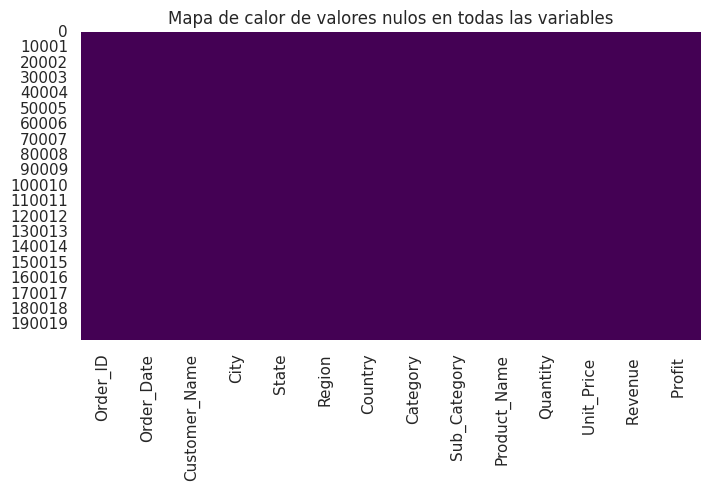

In [14]:
# ------------------------------------------------------------------------------
# mapa de calor de valores nulos
# ------------------------------------------------------------------------------
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Mapa de calor de valores nulos en todas las variables")
plt.show()


### 🔚 Conclusión

El dataset presenta **buena validez y unicidad**, pero requiere **acciones inmediatas** en **consistencia** para el uso de IA y etiqueta de aprobación de los estudiantes, así como en la **completitud** para las variables de herramienta y propósito de IA. 

La estrategia propuesta es **realista y medible**, y permitirá elevar la confiabilidad analítica del conjunto de datos, reduciendo riesgos de sesgo en decisiones y modelos.


asdasd

In [ ]:
# 1. Carga del conjunto de datos
file_path = 'product_sales_dataset_final.csv'
df = pd.read_csv(file_path)

# 2. Uso de PyJanitor para estandarizar nombres de columnas
# Esto soluciona de inmediato el problema de los espacios en blanco detectado anteriormente
df = df.clean_names()

print("--- Diagnóstico Inicial con Pandas y PyJanitor ---")

# A. Identificación de Valores Faltantes y Duplicados
missing_values = df.isnull().sum()
duplicate_rows = df.duplicated().sum()

# B. Identificación de Falta de Integridad y Unicidad
# Verificamos si Order_ID es único
is_unique_id = df['order_id'].is_unique
duplicate_ids = df['order_id'].duplicated().sum()

# C. Errores de Consistencia e Inexactitudes (Lógica de Negocio)
# Validamos la fórmula: $Revenue = Quantity \times Unit\_Price$
# Buscamos filas donde la diferencia sea mayor a un margen de error de 0.01
consistency_errors = df[abs(df['revenue'] - (df['quantity'] * df['unit_price'])) > 0.01]

# D. Errores de Formato
# Intentamos convertir a datetime para identificar registros con formato inválido
invalid_dates = pd.to_datetime(df['order_date'], errors='coerce').isna().sum()

# Imprimir Resumen de Hallazgos
print(f"Valores faltantes totales:\n{missing_values.sum()}")
print(f"Registros duplicados exactos: {duplicate_rows}")
print(f"¿El Order_ID es único?: {is_unique_id}")
print(f"IDs de Orden duplicados: {duplicate_ids}")
print(f"Errores de consistencia aritmética (Revenue): {len(consistency_errors)}")
print(f"Errores de formato en fechas: {invalid_dates}")

# 3. Generación del reporte exhaustivo con YData Profiling (Pandas Profiling)
# Este reporte generará visualizaciones de alertas, correlaciones y detalles por columna
profile = ProfileReport(
    df, 
    title="Reporte de Diagnóstico de Calidad - Ventas de Productos",
    explorative=True
)

# Guardar el reporte en formato HTML para su análisis en la bitácora
profile.to_file("diagnostico_calidad_ventas.html")

print("\n[INFO] El reporte detallado de Profiling ha sido generado como 'diagnostico_calidad_ventas.html'.")